In [1]:
import sys
from pathlib import Path

_SRC = Path("../src").resolve()
sys.path.insert(0, str(_SRC))

import jax
jax.config.update("jax_enable_x64", True)
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from plot.classification_plots import *

/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/src/plot/classification_plots.py:29: UserWarning: Seaborn not installed. Some plots may have reduced quality.
  warnings.warn("Seaborn not installed. Some plots may have reduced quality.")


In [53]:
p = "/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/results/jax_exp1bis_bary_baseline/river_series.npy"
p2 = "/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/results/jax_exp1bis_bary_baseline/river_bary_data.npy"
p3 = "/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/results/jax_exp1bis_bary_baseline/river_barycenters.npy"

In [54]:
data = np.load(p, allow_pickle=True).item()
bary_data = np.load(p2, allow_pickle=True).item()
barycenters = np.load(p3, allow_pickle=True).item()

In [55]:
data.keys(), bary_data.keys(), barycenters.keys()

(dict_keys(['X_train', 'y_train', 'X_test', 'y_test']),
 dict_keys(['wasps', 'eucl_params', 'eucl_raw']),
 dict_keys(['wasps', 'wasps_nodiv', 'eucl_params', 'eucl_params_nodiv', 'eucl_raw', 'eucl_raw_nodiv', 'sta']))

In [30]:
np.unique(data["y_test"], return_counts=True)
# samples_test = {key: data["X_test"][np.where(data["y_test"] == key)[0]] for key in np.unique(data["y_test"])}
samples_test = {}
for key in np.unique(data["y_test"]):
    idx = np.where(data["y_test"] == key)[0]
    for i in idx:
        if key not in samples_test:
            samples_test[key] = []
        samples_test[key].append(data["X_test"][i])
    samples_test[key] = np.array(samples_test[key])

In [32]:
samples_test[0].shape

(40, 52, 48)

In [49]:
bary_data["eucl_params"]["bary"]

{0: array([[17.10763403],
        [22.3575395 ],
        [27.68479905],
        [26.1325817 ],
        [28.59546609],
        [17.13707802],
        [15.18867238],
        [14.58035626],
        [15.76589533],
        [12.19425787],
        [14.08171209],
        [13.07083504],
        [14.28045444],
        [12.65507105],
        [12.94738691],
        [ 7.91590498],
        [ 5.6878836 ],
        [ 7.10538472],
        [ 8.21771531],
        [ 7.77418344],
        [ 6.454828  ],
        [ 4.73761301],
        [ 2.87450761],
        [ 3.16419432],
        [ 3.27352271],
        [ 3.67414082],
        [ 4.32868806],
        [ 7.25675051],
        [ 9.33585842],
        [10.08769928],
        [10.75448697],
        [13.03587695],
        [14.32288098],
        [14.93377653],
        [17.14965745],
        [15.57374628],
        [17.32219294],
        [15.54503963],
        [27.11425543],
        [14.87040908],
        [17.59343693],
        [ 9.60936487],
        [10.02966031],
        

AttributeError: 'list' object has no attribute 'strip'

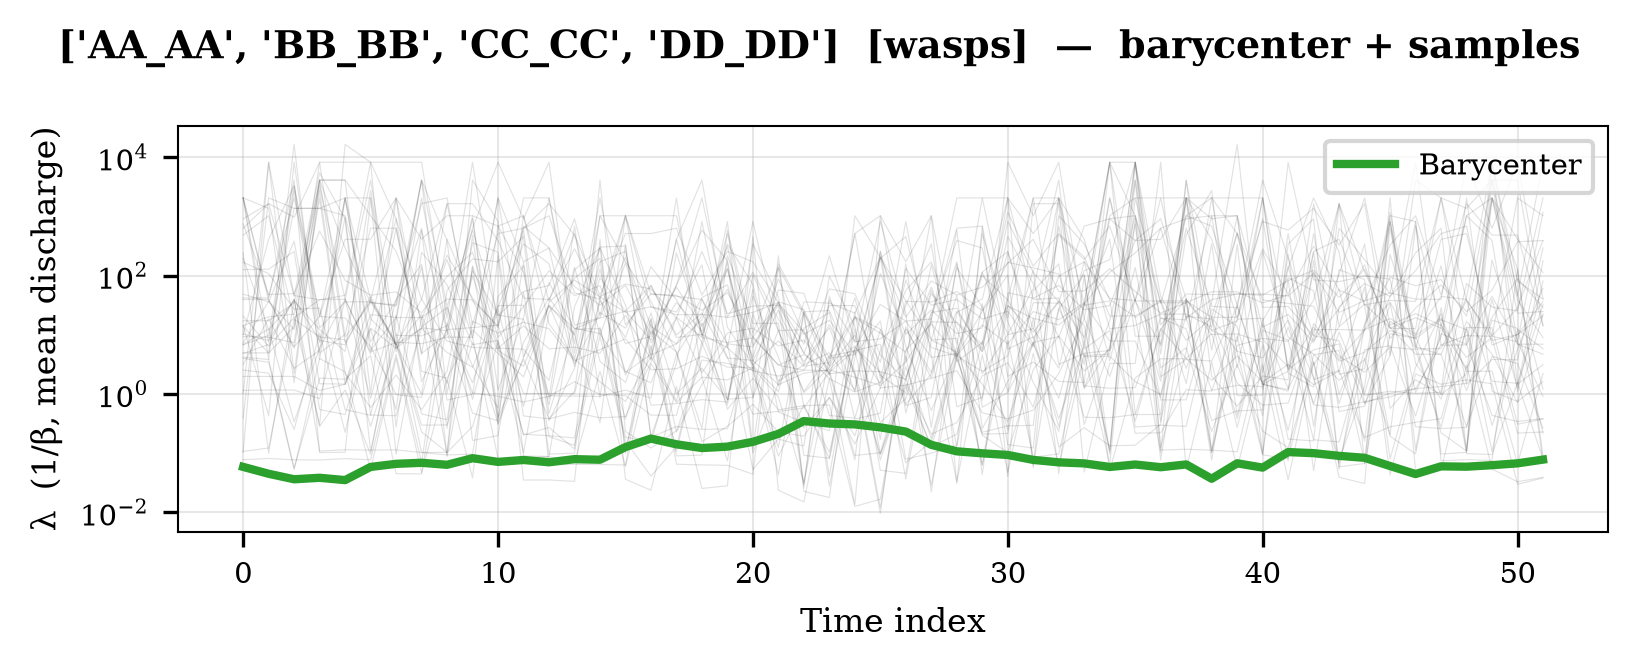

In [ ]:

def plot_class_pair_barycenters(barycenters_by_method: Dict[str, Dict[int, np.ndarray]],
                                 X_train_raw: List[np.ndarray],
                                 X_train_params: List[np.ndarray],
                                 Y_train: np.ndarray,
                                 idx_to_regime: Dict[int, str],
                                 output_dir: str = None,
                                 save_pdf: bool = True,
                                 n_samples: int = 10,
                                 show_legend: Union[bool, Sequence[bool], Mapping[Union[int, str], bool]] = True):
    """
    Plot one figure per class (all methods overlaid) with training sample traces.

    This function keeps its historical name for backward compatibility, but now
    creates individual class figures instead of class-pair figures.

    Figures are saved under ``<output_dir>/class_pairs/`` and exported in PDF
    only when ``save_pdf`` is True.

    Args:
        barycenters_by_method: Dict {method_key: {class_label: barycenter}}.
        X_train_raw: Unused (kept for API compatibility).
        X_train_params: List of parameter training arrays, each shape (T, 1).
        Y_train: Integer class labels for every training sample.
        idx_to_regime: {class_label: regime_code}, e.g. {0: 'PM', 1: 'PC'}.
        output_dir: Base output directory; figures saved under ``<output_dir>/class_pairs/``.
        save_pdf: Whether to save figures as PDF.
        n_samples: Number of sample traces to draw per class.
        show_legend: Legend visibility control.
            - bool: same value for all classes.
            - Sequence[bool]: one flag per class (ordered by sorted class labels).
            - Mapping[int|str, bool]: keyed by class label or regime code.
    """
    setup_ieee_style()

    def _sanitize_filename(text: str) -> str:
        safe = ''.join(ch if (ch.isalnum() or ch in ['_', '-']) else '_' for ch in text.strip())
        while '__' in safe:
            safe = safe.replace('__', '_')
        return safe.strip('_') or 'class'

    all_classes = sorted(next(iter(barycenters_by_method.values())).keys())
    T = X_train_params[0].shape[0]
    time_axis = pd.date_range(start='2019-01-01', periods=T, freq='D')

    legend_map = None
    legend_seq = None
    if isinstance(show_legend, Mapping):
        legend_map = dict(show_legend)
    elif isinstance(show_legend, (list, tuple, np.ndarray)) and not isinstance(show_legend, (str, bytes)):
        legend_seq = [bool(v) for v in show_legend]

    if output_dir:
        output_path = Path(output_dir) / "class_pairs"
        output_path.mkdir(parents=True, exist_ok=True)

    fig_width = 8./3.
    fig_height = 4./3.

    for class_label in all_classes:
        code = idx_to_regime.get(class_label, str(class_label))
        class_name = _CODE_TO_NAME_EN.get(code, code)

        if legend_map is not None:
            class_show_legend = bool(
                legend_map.get(class_label, legend_map.get(str(class_label), legend_map.get(code, True)))
            )
        elif legend_seq is not None:
            class_pos = all_classes.index(class_label)
            class_show_legend = legend_seq[class_pos] if class_pos < len(legend_seq) else True
        else:
            class_show_legend = bool(show_legend)

        class_indices = [i for i in range(len(X_train_params)) if Y_train[i] == class_label]
        rng_pre = np.random.RandomState(42 + class_label)
        rng_pre.shuffle(class_indices)

        y_sample_vals = []
        for idx in class_indices[:n_samples]:
            s = X_train_params[idx]
            vals = 1.0 / np.maximum(s[:, 0], 1e-10)
            y_sample_vals.append(vals)

        if y_sample_vals:
            all_sv = np.concatenate(y_sample_vals)
            pos = all_sv[all_sv > 0]
            y_lo = float(np.nanpercentile(pos, 1)) * 0.85
            y_hi = float(np.nanpercentile(pos, 99)) * 1.15
            y_lo = max(y_lo, 1e-3)
        else:
            y_lo, y_hi = 0.1, 1000.0

        _lw_sp = min(0.2, 0.7 * (5.0 / max(n_samples, 5)) ** 0.23)
        _al_sp = min(0.10, 0.5 * (5.0 / max(n_samples, 5)) ** 0.65)

        fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
        fig.subplots_adjust(bottom=0.28 if class_show_legend else 0.16, top=0.95, left=0.10, right=0.99)

        for idx in class_indices[:n_samples]:
            s = X_train_params[idx]
            ax.plot(time_axis, 1.0 / np.maximum(s[:, 0], 1e-10),
                    color='black', alpha=_al_sp, linewidth=_lw_sp)

        for method_key in _PAIR_METHODS:
            if method_key not in barycenters_by_method:
                continue
            bary = barycenters_by_method[method_key].get(class_label)
            if bary is None:
                continue

            if method_key == 'euclidean_raw':
                if bary.ndim > 1:
                    b = np.mean(bary, axis=tuple(range(1, bary.ndim)))
                else:
                    b = bary.ravel()
                b_plot = np.maximum(b, 1e-10)
            else:
                b_plot = 1.0 / np.maximum(bary[:, 0], 1e-10)

            ax.plot(time_axis, b_plot,
                    color=_METHOD_COLORS[method_key],
                    linewidth=1.2,
                    zorder=5)

        ax.set_yscale('log')
        ax.set_ylim(0.25 * y_lo, 10 * y_hi)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
        ax.tick_params(axis='x', rotation=0, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylabel(r'$\lambda\,(m^3/s)$', fontsize=8)
        ax.set_xlabel('Time', fontsize=8)
        ax.grid(True, alpha=0.3)

        if class_show_legend:
            legend_handles = [
                plt.Line2D([0], [0],
                           color=_METHOD_COLORS[m],
                           linewidth=1.2,
                           label=_METHOD_LABELS[m])
                for m in _PAIR_METHODS
                if m in barycenters_by_method
            ]
            legend_handles.append(
                plt.Line2D([0], [0], color='black', lw=0.8, alpha=0.5, label='Samples')
            )
            fig.legend(
                handles=legend_handles,
                loc='lower center',
                ncol=len(legend_handles),
                fontsize=6.5,
                bbox_to_anchor=(0.5, 0.03),
                frameon=True,
            )

        if output_dir and save_pdf:
            filename = _sanitize_filename(class_name)
            plt.savefig(output_path / f"{filename}.pdf", bbox_inches='tight', dpi=300)

        plt.show()

plot_class_pair_barycenters(barycenters_by_method=barycenters,
                                 X_train_raw=samples_test,
                                 X_train_params: List[np.ndarray],
                                 Y_train: np.ndarray,
                                 idx_to_regime: Dict[int, str],
                                 save_pdf=False,
                                 n_samples  = 100,
                                 show_legend: Union[bool, Sequence[bool], Mapping[Union[int, str], bool]] = True):
        
        
        plot_barycenter_debug(barycenters["eucl_params"]["bary"][0],
    samples_test[0][:],
    family="exponential",
    class_label=np.unique(data["y_test"])[0],
    class_name=["AA_AA","BB_BB","CC_CC","DD_DD"],
    method="wasps",
    n_samples= 100,
    output_dir="/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/results",
    save_pdf=True,
    )
plt.show()

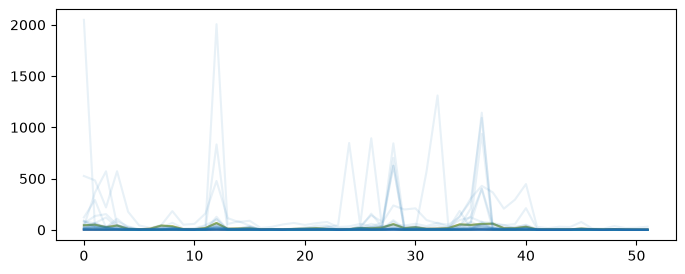

In [ ]:
plt.figure(figsize=(8, 3))
classe= 5
plt.semilogy(barycenters["wasps"]["bary"][classe], c='tab:orange', alpha=0.5, label="barycenter");
plt.semilogy(barycenters["eucl_params"]["bary"][classe], c='tab:green', alpha=0.5, label="euclidean barycenter");
plt.semilogy(1/barycenters["eucl_raw"]["bary"][classe].mean(axis=-1).T, c='tab:blue', alpha=0.5, label="euclidean raw barycenter");
plt.semilogy(1/barycenters["sta"]["bary"][classe].mean(axis=-1).T, c='tab:red', alpha=0.5, label="statistical barycenter");


plt.semilogy(1/samples_test[classe][:].mean(axis=-1).T, c='tab:blue', alpha=0.1);

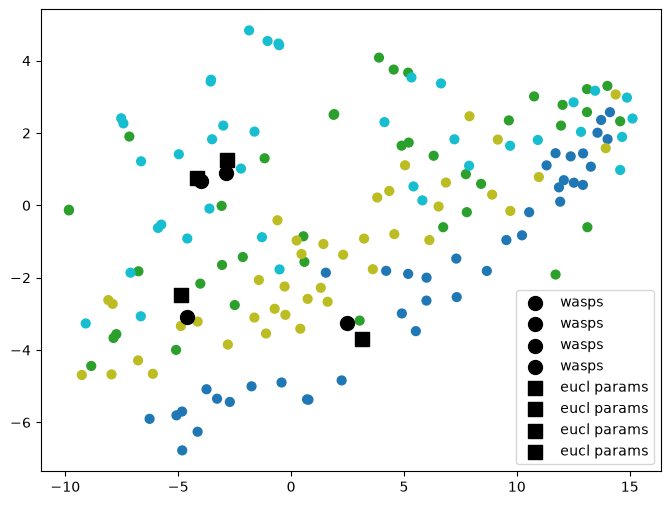

In [69]:

plt.figure(figsize=(8, 6))

idx_max = a["test_repr"].shape[0]
plt.scatter(tsn[:idx_max, 0], tsn[:idx_max, 1], c=a["test_labels"], cmap="tab10", s=40)
legend = ["wasps","eucl params"]#,"eucl raw"]
form = ["o", "s", "D"]
for i in range(len(legend)):
    for j in range(a["bary"].keys().__len__()):
        plt.scatter(tsn[idx_max + j + 4*i, 0], tsn[idx_max + j + 4 * i, 1], c="k", marker=form[i], s=100, label=legend[i])
plt.legend()
